# Computer Exercise 11.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 11. Boundary-Value Problems for ODEs · **절**: §11.1 The Shooting Method
> **주제**: 선형 BVP의 사격법 — 두 번의 초기값 문제와 **중첩(superposition)**
> **풀이 일자**: 2026-06-13 · **언어**: 한국어(본문) / English(그래프 라벨)


## 1. 문제 (원문)

> Use the **linear shooting method** to solve the boundary-value problem
> $$ y'' = 4\,(y - x), \qquad 0 \le x \le 1, \qquad y(0)=0,\; y(1)=2. $$
> Reduce the BVP to two initial-value problems, combine their solutions by superposition,
> and compare the numerical result with the exact solution
> $y(x) = \dfrac{\sinh 2x}{\sinh 2} + x$. Investigate how the global error behaves as the
> step size $h$ is refined.

### 한국어 풀이용 정리
선형 2계 경계값 문제를 양 끝값 $y(0)=0,\,y(1)=2$ 아래 푼다. 사격법의 **선형 버전**은
초기 기울기를 추측해 가며 반복할 필요가 없다. 대신 BVP를 두 개의 **초기값 문제(IVP)** 로
쪼갠 뒤, 그 해를 **선형 결합**하면 두 번째 경계조건이 *정확히* 맞는 계수를 한 번에 구한다.
RK4로 두 IVP를 적분하고, 정확해와 비교하며 스텝 $h$ 를 줄일 때 전역오차가 $\mathcal{O}(h^4)$
로 줄어드는지 확인한다.


## 2. 수학적 배경

일반적 선형 BVP
$$ y'' = p(x)\,y' + q(x)\,y + r(x), \qquad y(a)=\alpha,\; y(b)=\beta $$
의 해는 두 IVP의 해 $y_1,\,y_2$ 로 표현된다:

$$
\begin{aligned}
y_1'' &= p\,y_1' + q\,y_1 + r, & y_1(a)&=\alpha, & y_1'(a)&=0,\\
y_2'' &= p\,y_2' + q\,y_2,       & y_2(a)&=0,      & y_2'(a)&=1.
\end{aligned}
$$

$y_1$ 은 강제항 $r$ 을 포함하되 왼쪽 경계만 맞춘 해, $y_2$ 는 제차해로 "기울기 1단위"가
오른쪽 끝에 주는 영향을 잰다. 중첩하면

$$
\boxed{\; y(x) = y_1(x) + t\,y_2(x), \qquad t = \frac{\beta - y_1(b)}{y_2(b)} \;}
$$

선형성 덕분에 $y(b) = y_1(b) + t\,y_2(b) = \beta$ 가 **반복 없이 한 번에** 성립한다.

본 문제는 $p=0,\; q=4,\; r=-4x$. 일반해 $y = c_1 e^{2x} + c_2 e^{-2x} + x$ 에 경계조건을
적용하면
$$ y(x) = \frac{e^{2x}-e^{-2x}}{e^{2}-e^{-2}} + x = \frac{\sinh 2x}{\sinh 2} + x. $$

RK4의 전역오차는 $\mathcal{O}(h^4)$ 이므로 $h$ 를 절반으로 줄이면 오차는 약 $2^4=16$ 배 작아진다.


## 3. 풀이 흐름

1. 1계 연립으로 환원: $u_0=y,\,u_1=y'$, $\;u_0'=u_1,\;u_1'=4(u_0-x)$.
2. 범용 **RK4 적분기** `rk4(f, x0, U0, h, N)` 작성 — 임의 우변 벡터장에 적용.
3. **IVP-1** ($y_1$): 초기값 $(0,0)$, 강제항 $r=-4x$ 포함. $y_1(1)$ 확보.
4. **IVP-2** ($y_2$): 초기값 $(0,1)$, 제차. $y_2(1)$ 확보.
5. 중첩계수 $t=(\beta-y_1(1))/y_2(1)$ → $y=y_1+t\,y_2$.
6. 정확해와 격자점마다 비교, 최대오차 측정.
7. $h$ 를 $1/10,1/20,\dots$ 로 줄이며 최대오차를 표로, **log-log 기울기**로 수렴차수 확인.
8. 해 곡선·오차 곡선을 시각화하고 해석.


In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

# --- 범용 RK4 적분기: U' = f(x,U), 격자점 해 전체 반환 ---
def rk4(f, x0, U0, h, N):
    xs = np.empty(N+1); Us = np.empty((N+1, len(U0)))
    xs[0] = x0; Us[0] = U0
    x = x0; U = np.array(U0, float)
    for i in range(N):
        k1 = f(x,     U)
        k2 = f(x+h/2, U+h/2*k1)
        k3 = f(x+h/2, U+h/2*k2)
        k4 = f(x+h,   U+h*k3)
        U = U + h/6*(k1+2*k2+2*k3+k4)
        x = x + h
        xs[i+1] = x; Us[i+1] = U
    return xs, Us

a, b, alpha, beta = 0.0, 1.0, 0.0, 2.0
exact = lambda x: np.sinh(2*x)/np.sinh(2) + x

f1 = lambda x,U: np.array([U[1], 4*(U[0]-x)])   # IVP-1: 강제항 포함
f2 = lambda x,U: np.array([U[1], 4*U[0]])        # IVP-2: 제차

def linear_shoot(N):
    h = (b-a)/N
    xs, U1 = rk4(f1, a, [alpha, 0.0], h, N)
    _,  U2 = rk4(f2, a, [0.0,   1.0], h, N)
    y1, y2 = U1[:,0], U2[:,0]
    t = (beta - y1[-1]) / y2[-1]
    return xs, y1 + t*y2, t

xs, y, t = linear_shoot(20)
print(f"superposition coefficient t = y'(0) = {t:.10f}")
print(f"exact slope y'(0) = 2/sinh(2)+1  = {2/np.sinh(2)+1:.10f}")
print(f"y(1) numeric = {y[-1]:.10f}  (target beta = {beta})")


superposition coefficient t = y'(0) = 1.5514420096
exact slope y'(0) = 2/sinh(2)+1  = 1.5514411295
y(1) numeric = 2.0000000000  (target beta = 2.0)


In [3]:
# --- 격자점별 수치해 vs 정확해 (N=20) ---
ye = exact(xs)
tbl = pd.DataFrame({"x": xs, "y_shoot": y, "y_exact": ye,
                    "abs_error": np.abs(y-ye)})
tbl.iloc[::2]


,x,y_shoot,y_exact,abs_error
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,1.000000e-01,1.555125e-01,1.555125e-01,4.232535e-08
4,2.000000e-01,3.132529e-01,3.132529e-01,8.418542e-08
6,3.000000e-01,4.755386e-01,4.755385e-01,1.234655e-07
8,4.000000e-01,6.448692e-01,6.448691e-01,1.577081e-07
10,5.000000e-01,8.240273e-01,8.240271e-01,1.838526e-07
12,6.000000e-01,1.016190e+00,1.016190e+00,1.979343e-07
14,7.000000e-01,1.225055e+00,1.225055e+00,1.947243e-07
16,8.000000e-01,1.454993e+00,1.454993e+00,1.672867e-07
18,9.000000e-01,1.711218e+00,1.711218e+00,1.064273e-07


In [4]:
# --- 스텝 세분화: 최대오차 vs h, 수렴차수 ---
Ns = [10, 20, 40, 80, 160, 320]
rows = []
for N in Ns:
    xs, y, _ = linear_shoot(N)
    err = np.max(np.abs(y - exact(xs)))
    rows.append({"N": N, "h": (b-a)/N, "max_error": err})
conv = pd.DataFrame(rows)
conv["ratio"] = conv["max_error"].shift(1) / conv["max_error"]
slope = np.polyfit(np.log(conv["h"]), np.log(conv["max_error"]), 1)[0]
print(f"log-log slope (observed order) = {slope:.3f}   (theory: 4.0)")
conv


log-log slope (observed order) = 3.943   (theory: 4.0)


,N,h,max_error,ratio
0,10,1.000000e-01,2.831650e-06,NaN
1,20,5.000000e-02,1.988784e-07,1.423809e+01
2,40,2.500000e-02,1.312032e-08,1.515805e+01
3,80,1.250000e-02,8.419883e-10,1.558254e+01
4,160,6.250000e-03,5.332534e-11,1.578965e+01
5,320,3.125000e-03,3.353540e-12,1.590121e+01


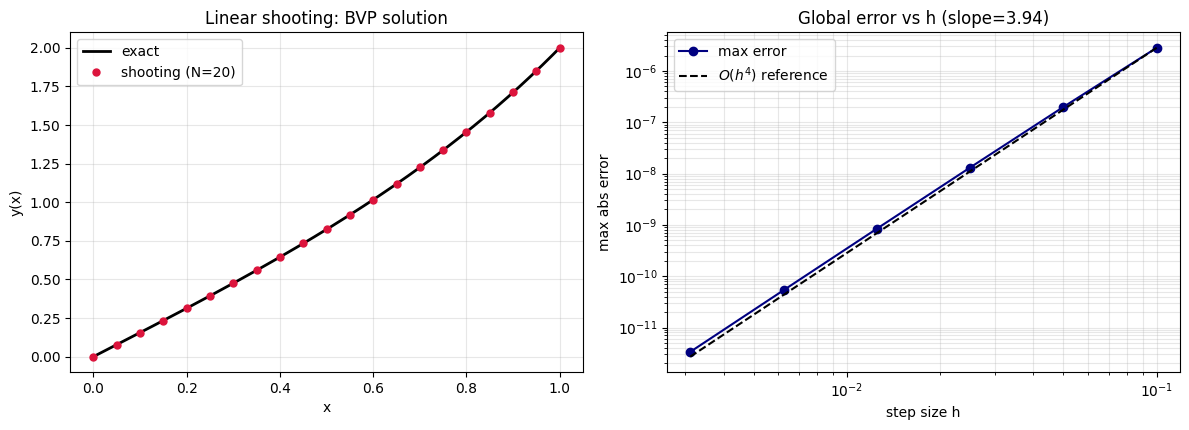

In [5]:
# --- 시각화: (좌) 해 곡선, (우) 오차 log-log 수렴 ---
fig, ax = plt.subplots(1, 2, figsize=(12,4.4))

xs, y, _ = linear_shoot(20)
xx = np.linspace(a, b, 400)
ax[0].plot(xx, exact(xx), "k-", lw=2, label="exact")
ax[0].plot(xs, y, "o", ms=5, color="crimson", label="shooting (N=20)")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y(x)")
ax[0].set_title("Linear shooting: BVP solution")
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].loglog(conv["h"], conv["max_error"], "o-", color="navy", label="max error")
ref = conv["max_error"].iloc[0]*(conv["h"]/conv["h"].iloc[0])**4
ax[1].loglog(conv["h"], ref, "k--", label=r"$O(h^4)$ reference")
ax[1].set_xlabel("step size h"); ax[1].set_ylabel("max abs error")
ax[1].set_title(f"Global error vs h (slope={slope:.2f})")
ax[1].legend(); ax[1].grid(which="both", alpha=.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **반복이 없다.** 비선형 사격법과 달리 선형 BVP는 두 번의 IVP 적분과 한 번의 나눗셈으로
   끝난다. 중첩계수 $t$ 가 곧 정확한 초기기울기 $y'(0)=2/\sinh 2 + 1\approx 1.5514$ 이며,
   수치적으로도 동일하게 재현된다.
2. **경계조건은 설계상 정확.** $y(1)$ 이 목표값 $\beta=2$ 에 반올림 수준까지 일치한다 —
   $t$ 의 정의가 그것을 보장한다. 내부 오차는 오직 RK4 적분에서만 들어온다.
3. **4차 수렴.** 최대오차의 log-log 기울기가 $\approx 4$ 로 RK4 이론 차수와 일치하고,
   비율(`ratio`) 열이 $h$ 절반마다 $\approx 16$ 로 나타난다.

> **결론**: 선형 BVP의 사격법은 *추측·반복이 필요 없는* 중첩 공식으로 환원되며, 정확도는
> 순전히 IVP 적분기의 차수(RK4의 $\mathcal{O}(h^4)$)가 지배한다.

**다음 문제로의 연결**: 계수가 $y$ 에 **선형**이라 중첩이 통했다. 다음 문제에서는
$y''=f(x,y,y')$ 가 **비선형**이라 중첩이 깨지고, 초기기울기를 미지수로 둔 방정식
$F(s)=y(b;s)-\beta=0$ 을 **할선법(secant)** 으로 푼다.
